# Introduction

Ontogenetic shifts in habitat niche use are a defining feature of marine predator life histories and play a critical role in shaping survival, growth, and population dynamics (De Roos, 2021,Dewar et al., 2004, Heupel & Huerter, 2002, Werner & Gilliam, 1984). For juvenile white sharks (JWS; Carcharodon carcharias), early life stages are constrained to shallow coastal nursery habitats that provide warm temperatures, high prey availability, and reduced predation risk, conditions that promote growth and increase survival during a vulnerable developmental period (De Roos & Persson, 2002, Dewar et al., 2004, Lowe et al., 2012, Weng et al., 2007). Many elasmobranch species exhibit stage-specific use of nearshore nurseries where juveniles benefit from high prey availability and reduced predation risk, followed by gradual expansion into deeper or more oceanic habitats as they approach maturity (Heupel & Huerter et al., 2002). Due to juvenile stages being spatially constrained and physiologically sensitive, changes in nursery habitat quality can have disproportionate effects on population dynamics (De Roos, 2021).

Historically, JWS nurseries along the U.S. West Coast were concentrated within the Southern California Bight (SCB), where nearshore embayment’s exhibit relatively warm and thermally stable conditions that support prolonged residency (Lowe et al., 2012, White et al., 2019). These regions functioned as consistent nurseries, with fine-scale acoustic telemetry tagging studies demonstrating strong site fidelity, restricted space use, and predictable residency patterns in these habitats (Spurgeon et al., 2022, Weng et al., 2007). Historically, Point Conception served as a biogeographic and thermal boundary for JWS, limiting sustained occupancy farther north due to colder, upwelling-dominated waters, and physiological thermal
tolerances (Tanaka et al., 2021). However, recent marine heatwaves and longer-term warming trends have weakened this boundary, coinciding with increased observations of JWS in the Monterey Bay (MB) (Santora et al., 2020, Tanaka et al., 2021). The MB differs fundamentally from historical nurseries in Southern California. It is characterized by strong seasonal upwelling, intense vertical mixing, and pronounced short-term thermal variability, resulting in cooler mean temperatures punctuated by seasonal warm surface conditions (Trautman & Walter, 2021). Although JWS presence has increased in this region, it remains unclear whether the MB represents a persistent nursery habitat or a seasonal thermal refuge occupied only during favorable environmental conditions. This distinction is critical, as presence alone does not indicate a functional nursery habitat. Juveniles may aggregate temporarily in response to short-lived thermal features without achieving the prolonged residency and habitat use patterns observed in historical nurseries. Resolving this uncertainty may require fine-scale juvenile movement and depth behavior with equally fine-scale measurements of thermal structure. This study directly addresses that gap by quantifying how thermal variability influences JWS residency, space use, and vertical habitat selection in the MB and by comparing these responses to those observed at a historically stable nursery (Padaro Baech, Santa Barbara) extensively documented in prior work (Spurgeon et al., 2022, Spurgeon et al., 2024).

In this final draft, I will be using a VEMCO Positioing System (VPS) array dataset collected by past CSULB Shark Lab master's student Emily Spurgeon in 2021. It is a .rds file that will help me analyze temperature and JWS movement behavior and residency within the array. As explained above, I will do my best to emphasize the importance on the reproducibility of this dataset that will aid in answering my broader thesis questions: (1)If warm, stratified surface waters develop within the MB, JWS will exhibit increased residency time, reduced horizontal displacement, and shallower mean depth use, consistent with behavioral thermoregulation observed in established nurseries and (2) If localized warm-water conditions at Seacliff State Beach function as effective thermal refuge within the broader, cooler MB system, then residency duration, and horizontal and vertical warm habitat selection will be greater than observed at the historical Santa Barbara nursery. But seasonal residency will be shorter if localized warming does not persist.

My main research question or hypothesis for this final project is:
    -Q1: Is there a relationship between mean water temperature and JWS residency inside the VPS array?
    -Ho: There is no relationship between mean water temperature and JWS residency inside the VPS array.
        -Ha: There is either a positive or negative relationship between mean water temperature and JWS residency inside the VPS array.

# Description of Methods and Data Source

The .rds file, prodived by Emily Spurgeon & the Shark Lab, are entered using the pyreadr package and converted into an applicable dataframe. After loading this file, I printed or read the file to display formatting of the data and columns. I then was helped by Emily Spurgeon on how how to clean the dataset to tailor for my specific project goals. Timestamps were converted to datetime, and temporal month/hour variables were simplified. Any columns with negative or inappropriate values, and NA values were filtered out because there was an error or malfunctioning in logging sensors.

First, the provided dataset was cleaned by removing NA values, transforming UTC time to Pacific Time, and creating new dataframes before generating figures. I then took raw detection counts of only 2 individual JWS within the array were visualized to display horizontal positioning across the array. This was done mostly for myself in learning how to visualize positioning, and to show the configuration of the array within its 5.2 km² range. If all individuals were coded into the figure, data points would be to cluststered. Next, I created spatial visualizations using detected coordinates in the array to depict the Horizontal Position Error (HPE), which is the measurement of precision of the recorded location (Kraft et al., 2023). Next, I created a subset containing the DateTimePT and DepthData, then month and hour variables from the df2021 dataframe. Mean hourly depth is calculated across each month. This was done using "for" loops for each month and hour, and calculating the mean depth in numpy. NaN were assigned if there were no values present, then filtered out in analysis. I visualized the dataset using a basic line plot, with hour of the day placed on the x-axis and mean depth in meters placed on the y-axis, while separate lines represents each month of the year. Lastly, I then created a bar chart to display the residency index (RI) values to show which indivduals may have spent the most time within the array. the RI equation was used from past acoustic telemetry tools to track fine-scale movement (Kraft et al., 2023). This was calculated as the proportion of days detected relative to the time between the first and last detection triangulated between three acoustic receivers in the array. With the totality of this code and data, they answer how JWS behave in nearshore environments vertically and horizontally. When all premilinary figures and data cleaning are successfully completed, I will then perform a scatterplot of mean temperature occupied by n=18 JWS in relationship to their residency time within the VPS array. This will be followed by a Shapiro test to determine normaility, then result in a Spearman's correlation analysis to tests whether there is a monotonic relationship between JWS residency and mean water temperature usage.

In [1]:
from vps_functions import residency_index
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import shapiro
import matplotlib.colors as colors

## Data loading/cleaning

In [2]:
file_path = "vps_data_subset.rds"
result = pyreadr.read_r(file_path)
df = result[None].copy()
print(df.shape)
print(df.columns)
df.head()

(186049, 21)
Index(['DateTimePT', 'DateTimeUTC', 'Transmitter', 'Tag_shortName', 'Latitude',
       'Longitude', 'HPE', 'TempData', 'DepthData', 'AccelData', 'Date',
       'Time', 'month', 'year', 'tag_family', 'when_encountered',
       'tag_location', 'capture_method', 'sex', 'TNL_cm',
       'est_tag_expiry_date'],
      dtype='object')


,DateTimePT,DateTimeUTC,Transmitter,Tag_shortName,Latitude,Longitude,HPE,TempData,DepthData,AccelData,...,Time,month,year,tag_family,when_encountered,tag_location,capture_method,sex,TNL_cm,est_tag_expiry_date
0,2021-06-01 04:00:29.353306112,2021-06-01 04:00:29.353306112,A69-1602-41962,2021-13,34.407004,-119.552286,4.908078,NaN,NaN,NaN,...,21:00:00,May,2021,V13-1x-BLU-3,4/1/2021,Del Mar,dart,M,152.0,3/9/2022
1,2021-06-01 04:02:23.118352896,2021-06-01 04:02:23.118352896,A69-9001-4339,2021-02,34.405452,-119.551313,6.119533,NaN,NaN,NaN,...,21:00:00,May,2021,V16-4x-069k-3,3/17/2021,Carpinteria,dart,F,183.0,3/16/2025
2,2021-06-01 04:03:52.210982912,2021-06-01 04:03:52.210982912,A69-1602-41962,2021-13,34.406659,-119.553018,5.873375,NaN,NaN,NaN,...,21:00:00,May,2021,V13-1x-BLU-3,4/1/2021,Del Mar,dart,M,152.0,3/9/2022
3,2021-06-01 04:06:01.224570112,2021-06-01 04:06:01.224570112,A69-1602-41962,2021-13,34.405990,-119.552941,4.518145,NaN,NaN,NaN,...,21:00:00,May,2021,V13-1x-BLU-3,4/1/2021,Del Mar,dart,M,152.0,3/9/2022
4,2021-06-01 04:07:08.218270976,2021-06-01 04:07:08.218270976,A69-9001-4324,2020-12,34.405461,-119.551035,4.715414,NaN,NaN,NaN,...,21:00:00,May,2021,V16-4x-069k-2,4/26/2020,Carpinteria,dart,F,230.0,4/25/2024


In [3]:
#Emily Spurgeon assistance with cleaning

In [4]:
df["DateTimePT"] = pd.to_datetime(df["DateTimePT"], errors="coerce")
df["DateTimeUTC"] = pd.to_datetime(df["DateTimeUTC"], errors="coerce")
df['year'] = df['DateTimePT'].dt.year
df['month'] = df['DateTimePT'].dt.month
df['day'] = df['DateTimePT'].dt.date
df['hour'] = df['DateTimePT'].dt.hour
df['year'] = df['DateTimeUTC'].dt.year
df['month'] = df['DateTimeUTC'].dt.month
df['day'] = df['DateTimeUTC'].dt.date
df['hour'] = df['DateTimeUTC'].dt.hour

In [5]:
df2021 = df[df['year'] == 2021].copy()
print(df2021.shape)
print(df2021[['year', 'month']].drop_duplicates().sort_values(['year', 'month']).head())

(186049, 23)
        year  month
0       2021      6
38684   2021      7
74475   2021      8
117507  2021      9
150076  2021     10


In [6]:
df2021 = df2021.dropna(subset=['Longitude', 'Latitude'])
df2021 = df2021.dropna(subset=['DepthData'])

In [7]:
df2021 = df2021.dropna(subset=['DateTimePT'])
df2021['day'] = df2021['DateTimePT'].dt.floor('D')
tags = sorted(df2021['Tag_shortName'].dropna().unique())
print(df2021)
print(tags)

                          DateTimePT                   DateTimeUTC  \
759    2021-06-01 19:46:17.835783936 2021-06-01 19:46:17.835783936   
764    2021-06-01 19:53:59.718046976 2021-06-01 19:53:59.718046976   
783    2021-06-01 20:19:12.788564992 2021-06-01 20:19:12.788564992   
787    2021-06-01 20:24:53.726191104 2021-06-01 20:24:53.726191104   
791    2021-06-01 20:27:24.554435072 2021-06-01 20:27:24.554435072   
...                              ...                           ...   
186035 2021-11-01 03:42:34.273235968 2021-11-01 03:42:34.273235968   
186037 2021-11-01 03:43:05.782657024 2021-11-01 03:43:05.782657024   
186039 2021-11-01 03:45:28.815681024 2021-11-01 03:45:28.815681024   
186042 2021-11-01 03:48:21.804258048 2021-11-01 03:48:21.804258048   
186045 2021-11-01 03:50:37.830880000 2021-11-01 03:50:37.830880000   

           Transmitter Tag_shortName   Latitude   Longitude       HPE  \
759      A69-9002-3593       2021-18  34.398915 -119.548158  7.179434   
764      A69-

In [8]:
#removing depth data with negative values (Emily said depth sensors were broken)

In [9]:
df2021 = df2021[df2021['DepthData'] >=0].copy()
print(df2021['DepthData'])

759       1.8194
764       1.8194
783       1.8194
787       1.8194
791       0.9097
           ...  
186035    6.3679
186037    3.6388
186039    1.8194
186042    0.0000
186045    7.2776
Name: DepthData, Length: 40234, dtype: float64


In [10]:
#Checking for how many individual JWS (n=...) have depth sensored tags

In [38]:
depth_sharks = df2021.dropna(subset=['DepthData'])
print(depth_sharks['Tag_shortName'].unique())
print("Number of individual JWS with depth data: 20")

['2021-18' '2021-19' '2021-20' '2021-22' '2021-15' '2021-23' '2021-26'
 '2021-27' '2021-28' '2021-31' '2021-35' '2021-37' '2021-36' '2021-43'
 '2021-44' '2021-45' '2021-46' '2021-47' '2021-49' '2021-50']
Number of individual JWS with depth data: 20


In [12]:
#Creating depth usage over time, in hourly intervals across months

In [13]:
depth_hourly = df2021[['DateTimePT', 'DepthData']].copy()
depth_hourly = depth_hourly.dropna(subset=['DepthData'])

In [14]:
#DateTimePT is datetime
depth_hourly['DateTimePT'] = pd.to_datetime(depth_hourly['DateTimePT'], errors='coerce')
depth_hourly = depth_hourly.dropna(subset=['DateTimePT'])

In [15]:
#Adding month and hour columns
depth_hourly['month'] = depth_hourly['DateTimePT'].dt.month
depth_hourly['hour'] = depth_hourly['DateTimePT'].dt.hour
print(depth_hourly.head())
print(depth_hourly.shape)

                       DateTimePT  DepthData  month  hour
759 2021-06-01 19:46:17.835783936     1.8194      6    19
764 2021-06-01 19:53:59.718046976     1.8194      6    19
783 2021-06-01 20:19:12.788564992     1.8194      6    20
787 2021-06-01 20:24:53.726191104     1.8194      6    20
791 2021-06-01 20:27:24.554435072     0.9097      6    20
(40234, 4)


In [16]:
#Make new, clean depth dataframe dropping NA values

In [17]:
depth_overtime = df2021[['DateTimePT','DepthData']].copy()
depth_overtime = depth_hourly.dropna(subset=['DepthData'])
depth_overtime['month'] = depth_hourly['DateTimePT'].dt.month
depth_overtime['hour'] = depth_hourly['DateTimePT'].dt.hour
print(depth_overtime.head())

                       DateTimePT  DepthData  month  hour
759 2021-06-01 19:46:17.835783936     1.8194      6    19
764 2021-06-01 19:53:59.718046976     1.8194      6    19
783 2021-06-01 20:19:12.788564992     1.8194      6    20
787 2021-06-01 20:24:53.726191104     1.8194      6    20
791 2021-06-01 20:27:24.554435072     0.9097      6    20


In [18]:
temp_df = df.dropna(subset=["TempData"]).copy()
print("Rows with temperature:", temp_df.shape)

Rows with temperature: (26472, 23)


# Results

### Preliminary Figures

Preliminary Figure 1

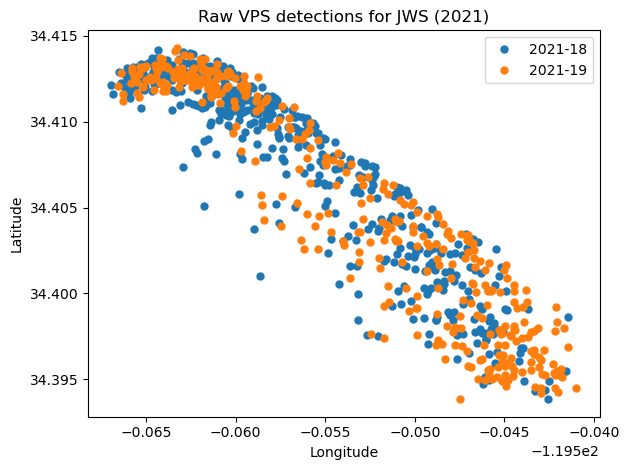

In [19]:
tags = df2021['Tag_shortName'].dropna().unique()

plt.figure()
for tag in tags[:2]:
    sub = df2021[df2021['Tag_shortName'] == tag]
    plt.plot(sub['Longitude'], sub['Latitude'], '.', ms=10, label=str(tag))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Raw VPS detections for JWS (2021)')
plt.legend()
plt.tight_layout()
plt.show()

Figure 1a: Displays the raw geo-positioning of two indivdual JWS within the Santa Barabar array.

Preliminary figure 2

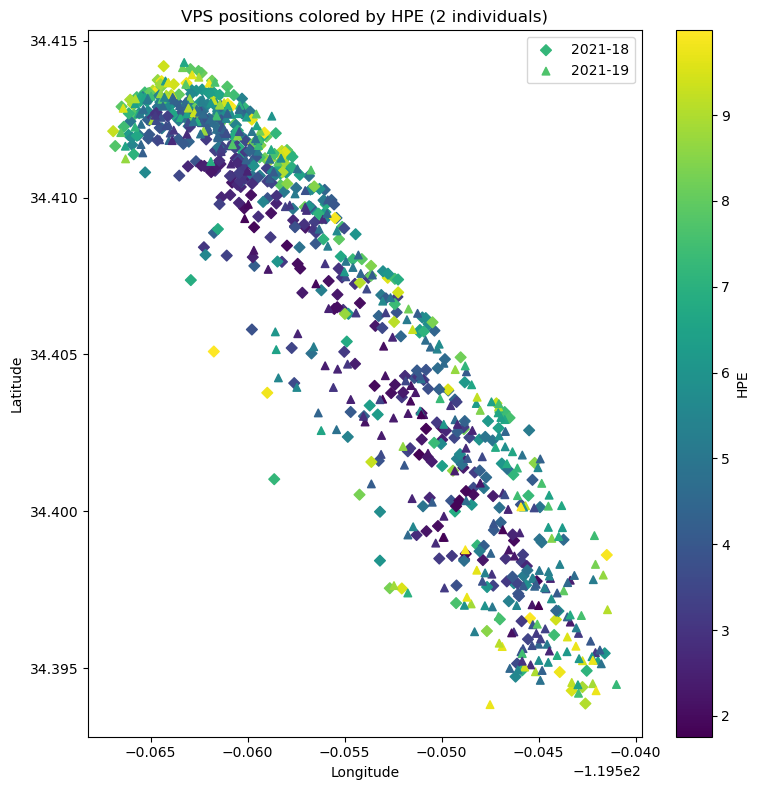

In [20]:
tags = df2021['Tag_shortName'].dropna().unique()

plt.figure(figsize=(8,8))
markers = ["D", "^"]
for i, tag in enumerate(tags[:2]):
    sub = df2021[
        (df2021['Tag_shortName'] == tag) &
        (df2021[['Longitude','Latitude','HPE']].notna().all(axis=1))]
    sc = plt.scatter(
    sub['Longitude'],
    sub['Latitude'],
    c=sub['HPE'],
    marker=markers[i],
    s=30,
    label=str(tag))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('VPS positions colored by HPE (2 individuals)')
plt.colorbar(sc, label='HPE')
plt.legend()
plt.tight_layout()
plt.show()

Figure 1b: A display of HPE of 2 particular JWS within the Santa Barbara VPS array. Color legend displays a gradient of high or low precision in tracking location. Darker points within the middle of the array tend to have higher accuracy in positioning, as oppose to the outer regions of the array.

Preliminary figure 3

In [21]:
month_list = np.sort(depth_overtime['month'].unique())
hour_list = np.arange(24)

depth_month_hour = []

for m in month_list:
    for h in hour_list:
        sub = depth_overtime[
            (depth_overtime['month'] == m) &
            (depth_overtime['hour'] == h)]
        if len(sub) > 0:
            mean_depth = np.mean(sub['DepthData'])
        else:
            mean_depth = np.nan
        depth_month_hour.append([m, h, mean_depth])
depth_month_hour = pd.DataFrame(depth_month_hour, columns=['month','hour','DepthData'])
print(depth_month_hour.head(10))

   month  hour  DepthData
0      6     0   1.863566
1      6     1   2.231164
2      6     2   2.712183
3      6     3   3.253269
4      6     4   2.080666
5      6     5   1.924926
6      6     6   1.828286
7      6     7   1.666831
8      6     8   1.769512
9      6     9   1.885608


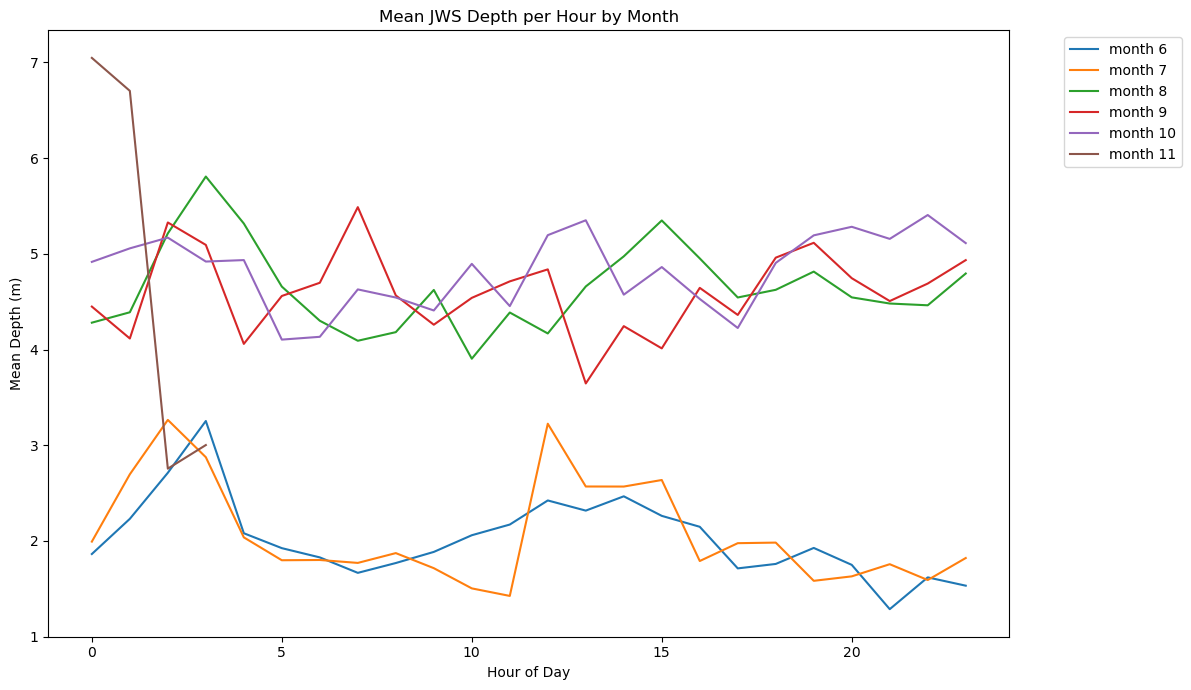

In [22]:
plt.figure(figsize=(12,7))

for m in month_list:
    sub = depth_month_hour[depth_month_hour['month'] == m]
    plt.plot(sub['hour'], sub['DepthData'], label='month ' + str(m))
plt.xlabel('Hour of Day')
plt.ylabel('Mean Depth (m)')
plt.title('Mean JWS Depth per Hour by Month')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

Figure 1c: Shows the available mean JWS (n=20) depth use by hour of day across the months occupying the VPS array. Colored lines represent the monthly mean depth use. Worth noting how much shallower in the water column JWS are in months June and July, indicating clear seasonal vertical distribution.

### Residency Index Analysis

In [23]:
tags = df2021['Tag_shortName'].dropna().unique()

ri_list = []

for tag in tags:
    sub = df2021[df2021['Tag_shortName'] == tag].copy()
    sub = sub.sort_values('DateTimePT')
    if len(sub) > 0:
        days_detected = len(sub['day'].dropna().unique())
        first_day = sub['day'].min()
        last_day = sub['day'].max()
        detection_interval = (last_day - first_day).days + 1
        ri = days_detected / detection_interval
        ri_list.append([tag, days_detected, first_day, last_day, detection_interval, ri])
ri_df = pd.DataFrame(
    ri_list,
    columns=['Tag_shortName', 'days_detected', 'first_day', 'last_day', 'detection_interval', 'RI'])
print(ri_df)

   Tag_shortName  days_detected  first_day   last_day  detection_interval  \
0        2021-18             21 2021-06-01 2021-06-23                  23   
1        2021-19             21 2021-06-01 2021-06-21                  21   
2        2021-20              1 2021-06-01 2021-06-01                   1   
3        2021-22             76 2021-06-02 2021-11-01                 153   
4        2021-15            132 2021-06-02 2021-11-01                 153   
5        2021-23             35 2021-06-02 2021-07-06                  35   
6        2021-26            145 2021-06-02 2021-10-31                 152   
7        2021-27            148 2021-06-02 2021-11-01                 153   
8        2021-28             22 2021-06-02 2021-06-23                  22   
9        2021-31             16 2021-07-23 2021-08-07                  16   
10       2021-35              7 2021-08-04 2021-10-29                  87   
11       2021-37             80 2021-08-13 2021-10-31                  80   

Secondary figure 1

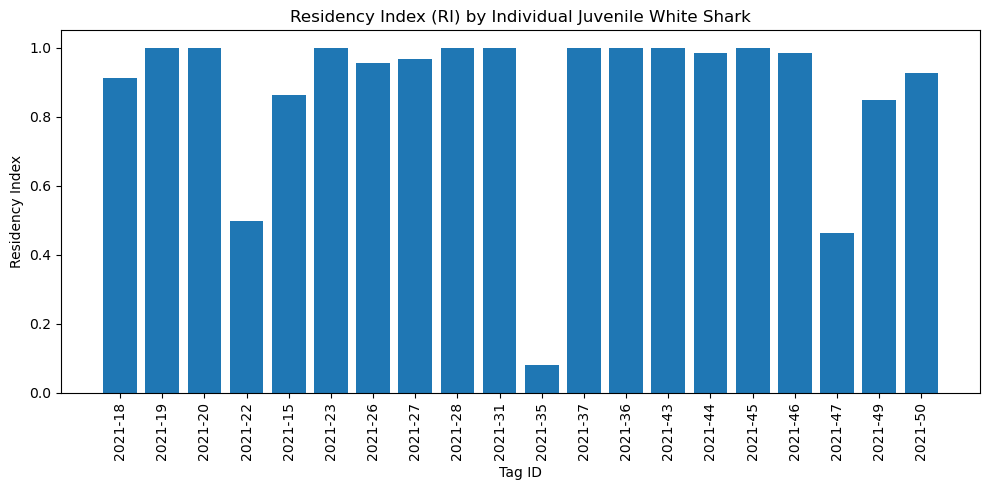

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    ri_df['Tag_shortName'],
    ri_df['RI'])
plt.xlabel("Tag ID")
plt.ylabel("Residency Index")
plt.title("Residency Index (RI) by Individual Juvenile White Shark")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Figure 2: Shows the RI values for each individual JWS (n=20) that entered the Santa Barbara VPS array. Higher values close to 1 indicate greater residency within the array, while lower values may indicate more transient use in the array.

#### Testing for RI and Temp

In [25]:
num_cols = ["Latitude", "Longitude", "HPE", "TempData", "DepthData"]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
df["sex"] = (df["sex"].astype(str).str.strip().str.upper())
df["sex"] = df["sex"].replace({
    "MALE": "M",
    "FEMALE": "F"})
df["DateOnly"] = df["DateTimePT"].dt.date
df = df.dropna(subset=["Tag_shortName"])
print(df.shape)

(186049, 24)


In [26]:
#Making df for total number of days in array and RI, then pair with avg temp

In [27]:
total_days = len(df["DateOnly"].unique())
tags = df["Tag_shortName"].dropna().unique()
ri_list = []

for tag in tags:
    sub = df[df["Tag_shortName"] == tag]
    days_detected = len(sub["DateOnly"].dropna().unique())
    ri_list.append([tag, days_detected])

ri_tmp = pd.DataFrame(ri_list, columns=["Tag_shortName", "days_detected"])
ri_tmp["RI"] = ri_tmp["days_detected"] / total_days
print("Total monitored days =", total_days)
print(ri_tmp.head())

Total monitored days = 154
  Tag_shortName  days_detected        RI
0       2021-13            152  0.987013
1       2021-02            151  0.980519
2       2020-12            144  0.935065
3       2020-40             59  0.383117
4       2020-36            137  0.889610


In [28]:
tags_temp = temp_df["Tag_shortName"].dropna().unique()
temp_list = []

for tag in tags_temp:
    sub = temp_df[temp_df["Tag_shortName"] == tag]
    temp_values = sub["TempData"].dropna()
    if len(temp_values) > 0:
        mean_temp = np.mean(temp_values)
        temp_list.append([tag, mean_temp])

temp_summary = pd.DataFrame(temp_list, columns=["Tag_shortName", "MeanTemp"])
print(temp_summary.head())

  Tag_shortName   MeanTemp
0       2021-19  17.308725
1       2021-20  16.017038
2       2021-18  17.573934
3       2021-21  13.545500
4       2021-15  17.994914


In [29]:
reg_df = pd.merge(ri_tmp, temp_summary, on="Tag_shortName")
print(reg_df.head())
print(reg_df.shape)

  Tag_shortName  days_detected        RI   MeanTemp
0       2021-19             21  0.136364  17.308725
1       2021-18             21  0.136364  17.573934
2       2021-20              1  0.006494  16.017038
3       2021-21              1  0.006494  13.545500
4       2021-15            138  0.896104  17.994914
(18, 4)


In [30]:
x = reg_df["MeanTemp"]
y = reg_df["RI"]

Preliminary figure 4

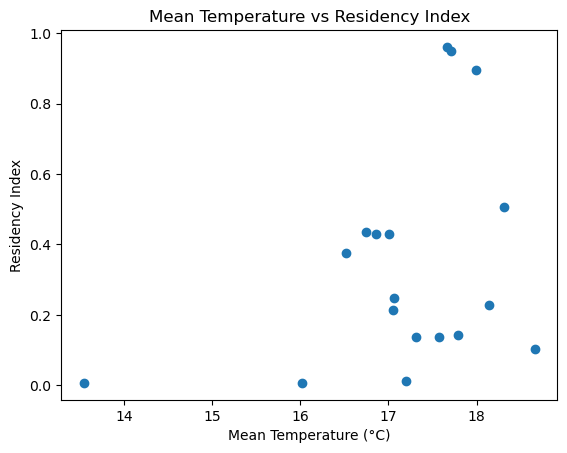

In [31]:
plt.scatter(x, y)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Residency Index")
plt.title("Mean Temperature vs Residency Index")
plt.show()

Figure 1d: is a preliminary scatterplot figure to visualize a relationship between RI and mean Temperature utilized by JWS within the array.

In [32]:
#Running a Shapiro test

In [33]:
shapiro(reg_df["MeanTemp"])

ShapiroResult(statistic=0.8311753273010254, pvalue=0.004336211364716291)

In [34]:
shapiro(reg_df["RI"])

ShapiroResult(statistic=0.8580539226531982, pvalue=0.011375229805707932)

### Due to the p < 0.05, assumptions of normality aren't met, leading to a Spearman's correlation analysis.

In [35]:
results = stats.spearmanr(x, y)
print(results)

SignificanceResult(statistic=0.2708013590547705, pvalue=0.2770801618623808)


In [36]:
results_line = stats.linregress(x, y)
slope = results_line.slope
intercept = results_line.intercept
yhat = slope * x + intercept
print(results_line)

LinregressResult(slope=0.0974629727192679, intercept=-1.3286573052858954, rvalue=0.35035949580479814, pvalue=0.15404531000289934, stderr=0.06513688990007259, intercept_stderr=1.120965761344815)


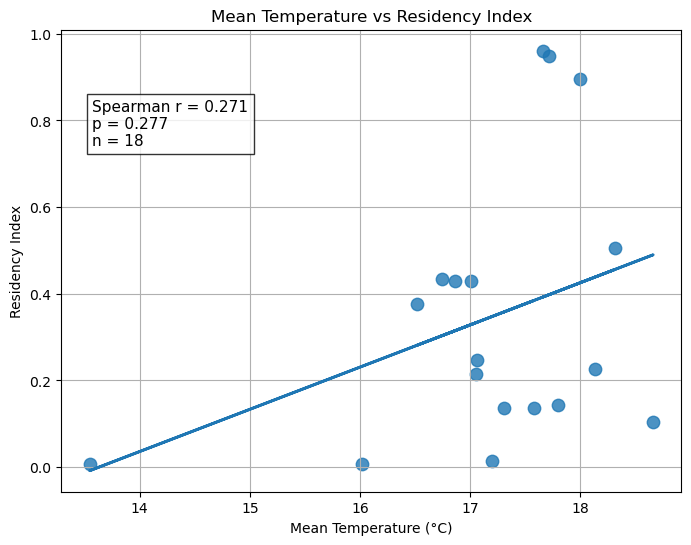

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=80, alpha=0.8)
plt.plot(x, yhat, linewidth=2)
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Residency Index")
plt.title("Mean Temperature vs Residency Index")
plt.text(0.05, 0.85,
    f"Spearman r = {results.statistic:.3f}\np = {results.pvalue:.3f}\nn = {len(reg_df)}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="black"))
plt.grid()
plt.show()

Figure 3: Displays a Spearman's Correlation between RI and Mean temperature usage. There are individuals of n=18 because not all had temperature sensors, or sensors were damaged (2 males and 16 females used for this analysis). This shows that there's a weak positive relationship between the residency behavior of JWS in nearshore environments and mean water temperatures. However, not strongly significant (Spearman's = p>0.05, r=0.271).

# Conclusion

The project analyzed whether mean water temperature was related to JWS residency within the Santa Barbara VPS array. The preliminary results, on a subset of data, showed a weak positive relationship between mean temperature and RI, where individuals who occupied warmer mean water temperatures tended to exhibit higher residency values. However, there was a weak positive relationship that was not statistically significant, suggesting that there may have been other factors that could explain high residency usage (Spearman's p>0.05, r=0.271). In addition, only having a fragment of the full datatset, containing 40+ different individuals, could significantly change my results. Exploratory figures of raw detections, HPE, and depth usage helped plainly display how JWS interacts within this nearshore environment.

# Ideas For Future Work

For future work, I may want to potentially use a temperature model called the Feed Forward Neural Network (FFNN) to asign temperatures values to JWS throughout their vertical and horizontal movement (Anderson et al., 2022).This FFNN temperature model can also be a stepping stone to building predictive model in determining for determining if Seacliff State Beach will emerge as the new northern edge, fully functional nursery ground for JWS. In the near future, I will be able to incorporate temperature loggers into my VPS mooring system for my thesis project, allowing to capture SST to seafloor temperatures to caption fine-scale thermal changes in a dynamic environment at Seacliff State Beach. The VPS array that will be deployed in the MB, will also capture any other acoustically tagged animal that passes within the array, so spatial and temporal distributions of other species at a fine scale can also be analyzed to investigate how they're partitioning in this environment with the charismatic mesopredators.

# AI Statement

Limited use of AI-assisted tools such as ChatGPT is allowed for this assignment, if properly documented and tested. All projects must how have an AI statement describing if and how AI tools were used in the project, as is the case for many scientific journals now.

If AI tools were used to develop any portion of code for analysis, the statement should specifically describe each portion of AI-generated analysis code. There should be documentation describing in detail how the code works, as well as how you reviewed and tested the code for accuracy. Examples of tests may be provided in a separate notebook if necessary. This is good practice for human-generated code as well.

AI tools may be used to check text for grammar and clarity. If used in this manner, this can be generally acknowledged in the AI statement without specifying each instance. AI tools may not be used to generate substantial portions of text.

AI tools may also be used to assist with purely cosmetic enhancements to figures to effectively display information in graphics. If used in this manner, this can be generally acknowledged in the AI statement without specifying each instance.

"Vibe coding" substantial portions of untested AI-generated code without a strong understanding what the code is doing is poor scientific practice. This approach can feel like progress at first, but often results in a maze of broken code when you want to modify something or adapt it for a new use case.

Use of open source code is allowed if properly acknowledged in accordance with the software's license.

No use of AI for coding on this assignment, only assistance for troubleshooting code from data owner Emily Spurgeon.

# References

Anderson James M., Emily Spurgeon., Brian S. Stirling, Jack May III, Patrick T. Rex,
Bobby Hyla, Steve McCullough, Marten Thompson, Christopher G. Lowe. “High
resolution acoustic telemetry reveals swim speeds and inferred field metabolic rates in
juvenile white sharks (Carcharodon carcharias).” PLOS ONE 17 (2022):
(6). https://doi.org/10.1371/journal.pone.0268914.

De Roos Andre M. Dynamic population stage structure due to juvenile-adult asymmetry
stabilizes complex ecological communities. Proc Natl Acad Sci U S A 118 (2021): (21).
e2023709118. https://doi:10.1073/pnas.2023709118.

De Roos, Andre M., Lennart Persson. “Size-dependent life-history traits promote
catastrophic collapses of top predators.” Proc. Natl. Acad. Sci. U.S.A. 99 (2002): (20)
12907-12912. https://doi.org/10.1073/pnas.192174199.

Dewar, Heidi., Michael Domeier. & Nicole Nasby-Lucas. “Insights into Young of the
Year White Shark, Carcharodon carcharias, Behavior in the Southern California
Bight.” Environmental Biology of Fishes 70 (2004): 133–143.
https://doi.org/10.1023/B:EBFI.0000029343.54027.6a.

Heupel, Michelle R., & Robert Hueter. “Importance of prey density in relation to the
movement patterns of juvenile blacktip sharks (Carcharhinus limbatus) within a coastal
nursery area.” Marine and Freshwater Research 53 (2002): 543-550.
https://doi.org/10.1071/MF01132.

Kraft et al. "Residency and space use estimation methods based on passive acoustic telemetry data." Movement Ecology (2023) 11:12 https://doi.org/10.1186/s40462-022-00364-z

Lowe, Christopher, Mary Blasius, Erica Jarvis Mason, Tom Mason, Gwen
Goodmanlowe, John O’Sullivan. “Historic Fishery Interactions with White Sharks in the
Southern California Bight.” (2012). https://doi.org/10.1201/b11532-17.

Santora, Jarrod A., Nathan J. Mantua, Isaac D. Schroeder, John C. Field, Elliot L. Hazen,
Steven J.Bograd, William J. Sydeman, Brian K. Wells, John Calambokidis, Lauren Saez,
Dan Lawson, Karin A. Forney. “Habitat compression and ecosystem shifts as potential
links between marine heatwave and record whale entanglements.” Nat Commun 11
(2020) (1): 536. https://doi.org/10.1038/s41467-019-14215-w.

Spurgeon, Emily, James M. Anderson, Yi Liu, Vianey Leos Barajas, Christopher G.
Lowe. “Quantifying thermal cues that initiate mass emigrations in juvenile white
sharks.” Sci Rep 12 (2022): 19874. https://doi.org/10.1038/s41598-022-24377-1.

Spurgeon, Emily, Marten L. Thompson, Mitchell D. Alexander, James M. Anderson,
Patrick T. Rex, Brian Stirling, Kevin Abbott. Christopher G. Lowe. “The influence of
micro-scale thermal habitat on the movements of juvenile white sharks in their Southern
California aggregation sites.” Front. Mar. Sci 11 (2024): 1290769.
https://doi.org/10.3389/fmars.2024.1290769.

Tanaka, Kisei R., Kyle S. Van Houtan, Eric Mailander, Beatriz S. Dias, Carol Galginaitis,
John O’ Sullivan, Christopher G. Lowe, Salvador J. Jorgensen. “North Pacific warming
shifts the juvenile range of a marine apex predator.” Sci Rep 11 (2021): 3373.
https://doi.org/10.1038/s41598-021-82424-9.

Trautman, Nicholas, Ryan K. Walter. “Seasonal variability of upwelling and downwelling
surface current patterns in a small coastal embayment.” Continental Shelf Research 226
(2021). https://doi.org/10.1016/j.csr.2021.104490.

Weng, Kevin C., John O’Sullivan, Christopher G. Lowe, Chuck E. Winkler, Heidi Dewar,
Barabara A. Block. “Movements, behavior and habitat preferences of juvenile white
sharks Carcharodon carcharias in the eastern Pacific.” Mar Ecol Prog Ser 338 (2007):
211-224. https://doi.org/10.3354/meps338211.

Werner, Earl. E., James F. Gilliam. “The Ontogenetic Niche and Species Interactions in
Size-Structured Populations.” Annual Review of Ecology and Systematics 15 (1984): 393-
425. https://doi.org/10.1146/annurev.es.15.110184.002141.

White, Connor F., Kady Lyons, Salvador J. Jorgensen, John O'Sullivan, Chuck Winkler,
Kevin C. Wong, Christopher G. Lowe. “Quantifying habitat selection and variability in
habitat suitability for juvenile white sharks.” PLOS ONE 14 (2019):
(5). https://doi.org/10.1371/journal.pone.0214642.